# Inria Dataset
Semantic segmentation on Inria Aerial Image Labeling Dataset

View Inria Aerial Image Labeling Dataset before training

Training is in `run_inria.ipynb`

Sep 03rd 2026

## Setup

Install TorchGeo

In [1]:
# Works in VS Code .venv Python 3.11.7

%pip install torchgeo==0.7.1


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import tempfile

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from torchgeo.datasets import InriaAerialImageLabeling
from torchgeo.datamodules import InriaAerialImageLabelingDataModule

In [3]:
# Settings used in more than one line below

data_dir='/Users/nball/Data/Geo/TorchGeo' # Note not /AerialImageDataset/

## Dataset

In [4]:
# https://docs.torchgeo.org/en/stable/api/datasets/inria-aerial-image-labeling.html
# https://github.com/torchgeo/torchgeo/blob/main/torchgeo/datasets/inria.py#L31-L254

dataset = InriaAerialImageLabeling(root=data_dir)

In [ ]:
dataset.files

[{'image': '/Users/nball/Data/Geo/TorchGeo/AerialImageDataset/train/images/austin10.tif',
  'label': '/Users/nball/Data/Geo/TorchGeo/AerialImageDataset/train/gt/austin10.tif'},
 {'image': '/Users/nball/Data/Geo/TorchGeo/AerialImageDataset/train/images/austin11.tif',
  'label': '/Users/nball/Data/Geo/TorchGeo/AerialImageDataset/train/gt/austin11.tif'},
 {'image': '/Users/nball/Data/Geo/TorchGeo/AerialImageDataset/train/images/austin12.tif',
  'label': '/Users/nball/Data/Geo/TorchGeo/AerialImageDataset/train/gt/austin12.tif'},
 {'image': '/Users/nball/Data/Geo/TorchGeo/AerialImageDataset/train/images/austin13.tif',
  'label': '/Users/nball/Data/Geo/TorchGeo/AerialImageDataset/train/gt/austin13.tif'},
 {'image': '/Users/nball/Data/Geo/TorchGeo/AerialImageDataset/train/images/austin14.tif',
  'label': '/Users/nball/Data/Geo/TorchGeo/AerialImageDataset/train/gt/austin14.tif'},
 {'image': '/Users/nball/Data/Geo/TorchGeo/AerialImageDataset/train/images/austin15.tif',
  'label': '/Users/nball/

## Data module

In [9]:
# TorchGeo docs

# https://torchgeo.readthedocs.io/en/stable/api/datamodules.html#inria-aerial-image-labeling
# https://torchgeo.readthedocs.io/en/stable/api/datamodules.html#nongeodatamodule

# TorchGeo sources

# https://github.com/torchgeo/torchgeo/blob/main/torchgeo/datamodules/inria.py
# https://github.com/torchgeo/torchgeo/blob/main/torchgeo/datasets/inria.py
# https://github.com/torchgeo/torchgeo/blob/main/torchgeo/datamodules/geo.py

datamodule = InriaAerialImageLabelingDataModule(
    patch_size=1024,
    num_workers=2,
    root=data_dir
)

datamodule

In [10]:
datamodule.setup('fit') # Sets up training and validation datasets
datamodule.setup('predict') # Sets up prediction dataset

In [11]:
datamodule.train_dataset[0]

{'image': tensor([[[167., 100., 102.,  ...,  68.,  74.,  54.],
          [103., 110., 108.,  ...,  89.,  87.,  77.],
          [112., 110., 119.,  ..., 105.,  80.,  59.],
          ...,
          [199., 197., 191.,  ...,  82.,  92.,  96.],
          [213., 206., 201.,  ...,  90., 104.,  84.],
          [213., 208., 188.,  ..., 105., 106.,  76.]],
 
         [[170.,  97., 101.,  ...,  65.,  76.,  54.],
          [101., 109., 107.,  ...,  90.,  88.,  79.],
          [113., 109., 116.,  ..., 104.,  82.,  58.],
          ...,
          [196., 195., 190.,  ...,  80.,  90.,  94.],
          [211., 204., 200.,  ...,  88., 104.,  82.],
          [215., 212., 195.,  ..., 104., 105.,  73.]],
 
         [[172., 102., 102.,  ...,  59.,  72.,  50.],
          [ 99., 113., 110.,  ...,  83.,  86.,  77.],
          [113., 109., 125.,  ...,  93.,  75.,  54.],
          ...,
          [182., 176., 171.,  ...,  76.,  87.,  91.],
          [200., 189., 183.,  ...,  83., 100.,  75.],
          [203., 198.,

In [12]:
datamodule.val_dataset[0]

{'image': tensor([[[123., 124., 124.,  ..., 103., 113., 108.],
          [125., 126., 124.,  ..., 105., 113., 108.],
          [124., 124., 124.,  ..., 106., 115., 111.],
          ...,
          [ 38.,  27.,  34.,  ...,  93.,  43.,  43.],
          [ 36.,  37.,  44.,  ...,  44.,  43.,  41.],
          [ 37.,  50.,  42.,  ...,  41.,  40.,  83.]],
 
         [[127., 128., 126.,  ...,  99., 110., 108.],
          [129., 131., 127.,  ..., 102., 110., 108.],
          [128., 127., 126.,  ..., 104., 111., 109.],
          ...,
          [ 47.,  31.,  38.,  ...,  90.,  38.,  34.],
          [ 44.,  44.,  50.,  ...,  39.,  40.,  35.],
          [ 44.,  59.,  48.,  ...,  39.,  37.,  75.]],
 
         [[121., 123., 121.,  ...,  90.,  99.,  95.],
          [124., 127., 123.,  ...,  93.,  96.,  94.],
          [124., 123., 123.,  ...,  95.,  97.,  95.],
          ...,
          [ 45.,  27.,  37.,  ...,  84.,  34.,  32.],
          [ 43.,  45.,  54.,  ...,  32.,  37.,  30.],
          [ 44.,  64.,

In [13]:
datamodule.predict_dataset[0]

{'image': tensor([[[ 92.,  87.,  82.,  ...,  88.,  69.,  73.],
          [ 92., 100.,  80.,  ...,  96.,  94.,  94.],
          [104., 117.,  95.,  ..., 112., 112.,  99.],
          ...,
          [ 74.,  70.,  72.,  ..., 113., 127., 117.],
          [ 71.,  73.,  77.,  ..., 103., 122., 116.],
          [ 69.,  72.,  79.,  ..., 107., 122., 117.]],
 
         [[102.,  95.,  86.,  ..., 100.,  79.,  85.],
          [100., 105.,  82.,  ..., 107., 106., 107.],
          [118., 124., 101.,  ..., 129., 124., 112.],
          ...,
          [ 88.,  80.,  74.,  ..., 118., 135., 122.],
          [ 83.,  83.,  79.,  ..., 104., 133., 122.],
          [ 81.,  82.,  82.,  ..., 110., 133., 122.]],
 
         [[ 62.,  59.,  52.,  ...,  74.,  47.,  52.],
          [ 66.,  74.,  53.,  ...,  80.,  74.,  74.],
          [ 87.,  97.,  73.,  ..., 100.,  93.,  80.],
          ...,
          [ 74.,  69.,  67.,  ...,  94., 115., 102.],
          [ 72.,  72.,  73.,  ...,  77., 109., 100.],
          [ 69.,  72.,

## Dataset information

In [14]:
print(datamodule.train_dataset[0]['image'].shape)
print(datamodule.train_dataset[0]['mask'].shape)
print(datamodule.val_dataset[0]['image'].shape)
print(datamodule.val_dataset[0]['mask'].shape)
print(datamodule.predict_dataset[0]['image'].shape)

torch.Size([3, 5000, 5000])
torch.Size([5000, 5000])
torch.Size([3, 5000, 5000])
torch.Size([5000, 5000])
torch.Size([3, 5000, 5000])


In [15]:
# Number of images in each dataset (AI code)
print(f"Number of training images: {len(datamodule.train_dataset)}")
print(f"Number of validation images: {len(datamodule.val_dataset)}")
print(f"Number of prediction images: {len(datamodule.predict_dataset)}")

Number of training images: 155
Number of validation images: 25
Number of prediction images: 180


## Plots

In [ ]:
# Data is ordered by filename rather than city names

# Train

# Area                  No. images   Indices   Filename

# Austin, TX            31           0-30      austin
# Chicago, IL           31           31-61     chicago
# Kitsap county, WA     31           62-92     kitsap
# West Tyrol, Austria   31           93-123    tyrol-w
# Vienna, Austria       31           124-154   vienna

# Validation: First 5 images of each area in training dataset

# Area                  No. images   Indices   Filename

# Austin, TX            5            0-4       austin
# Chicago, IL           5            5-9       chicago
# Kitsap county, WA     5            10-14     kitsap
# West Tyrol, Austria   5            15-19     tyrol-w
# Vienna, Austria       5            20-24     vienna

# Test

# Area                  No. images   Indices   Filename

# Bellingham, WA        36           0-35      bellingham
# Bloomington, IN       36           36-71     bloomington
# Innsbruck, Austria    36           72-107    innsbruck
# San Francisco, CA     36           108-143   sfo
# East Tyrol, Austria   36           144-179   tyrol-e

In [127]:
# To plot, vary these and run this cell and those below

idx_tr = 154
idx_val = 24
idx_pr = 179

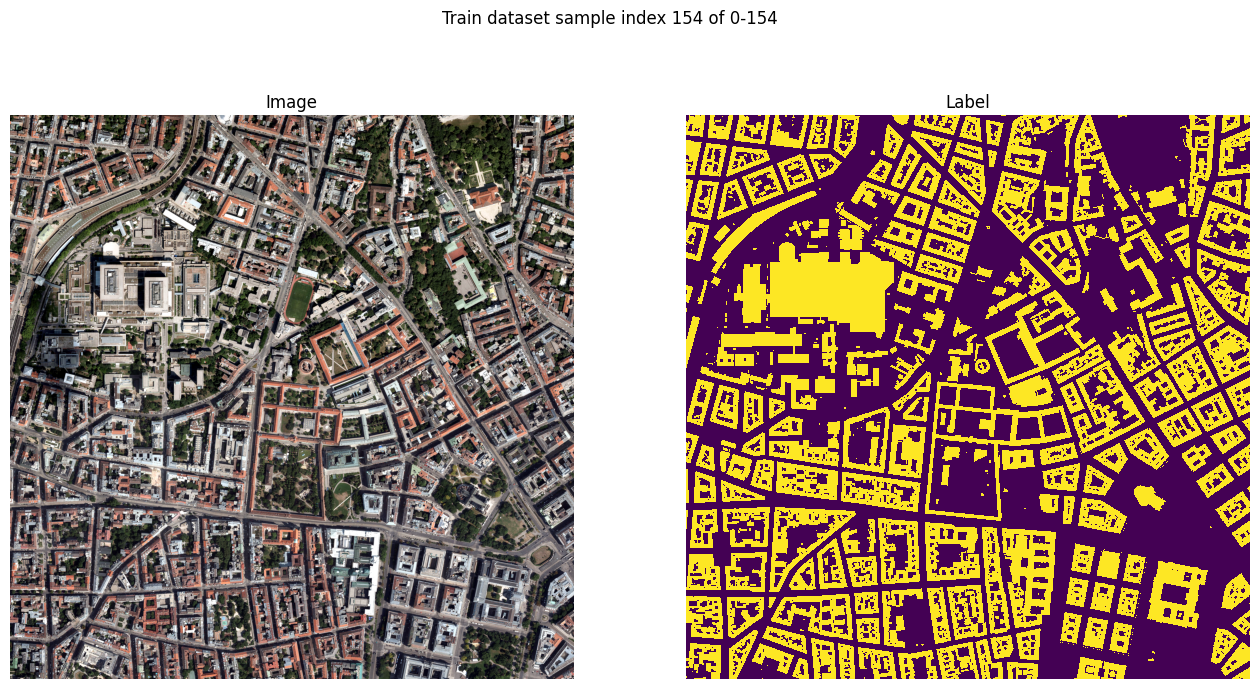

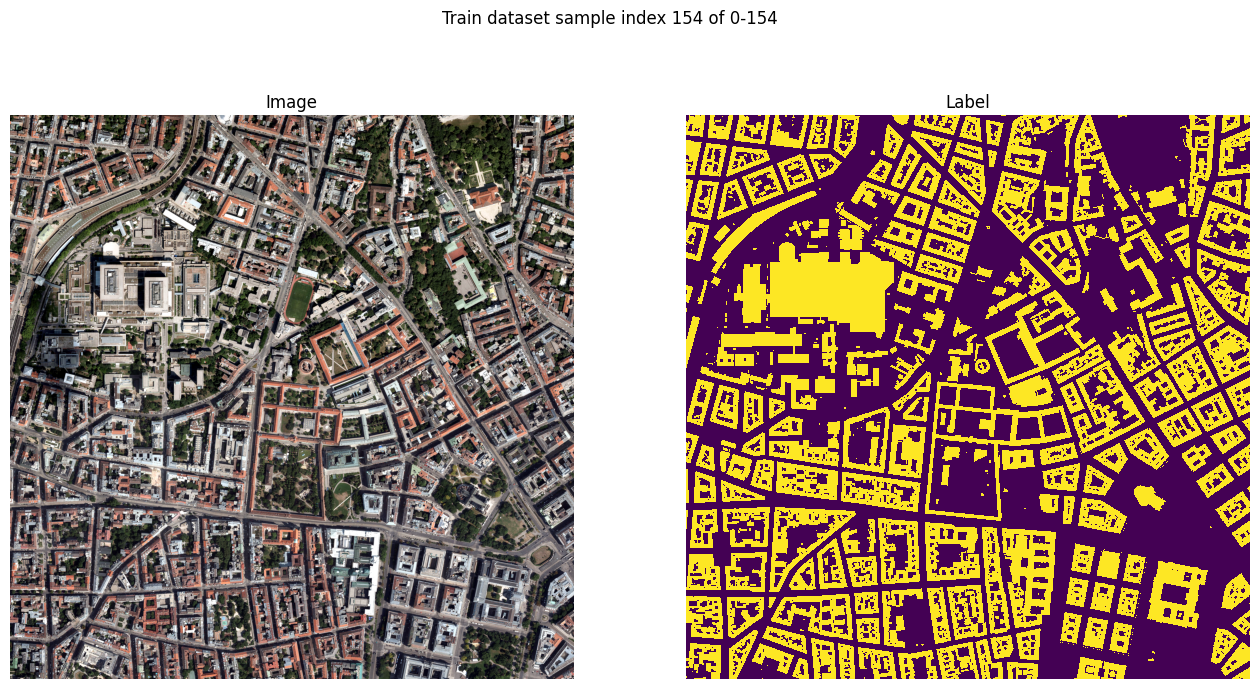

In [128]:
sample = datamodule.train_dataset[idx_tr]
datamodule.plot(sample, suptitle=f"Train dataset sample index {idx_tr} of 0-154")

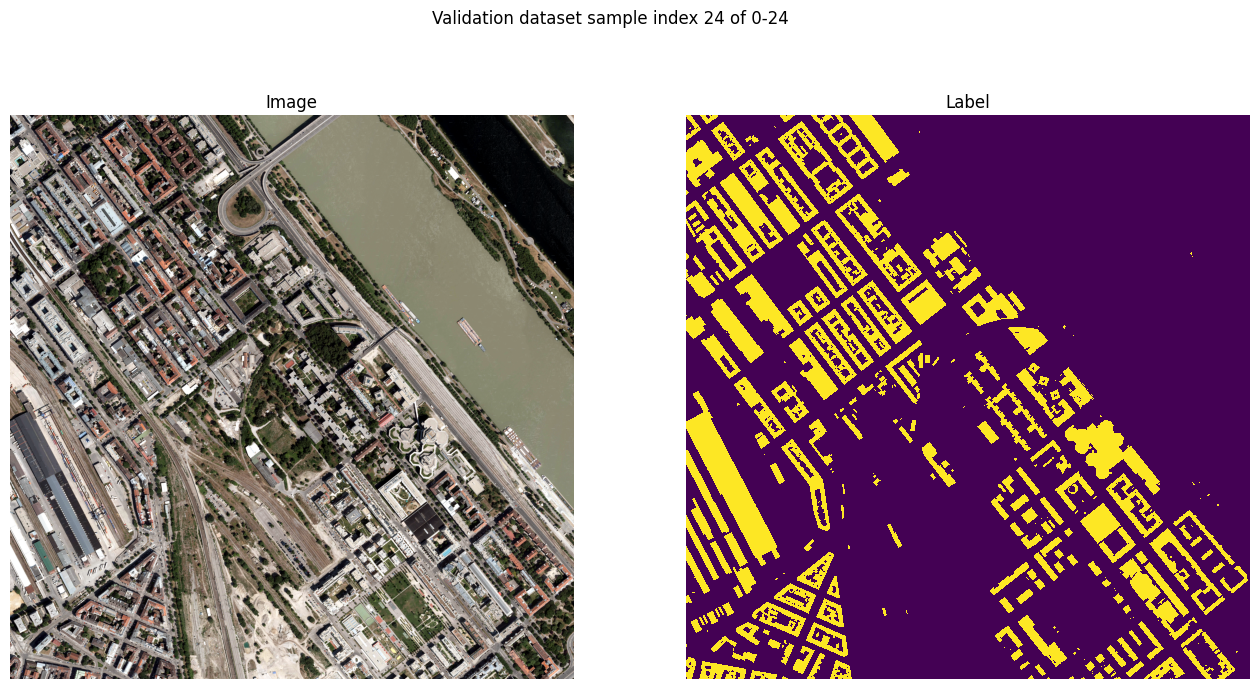

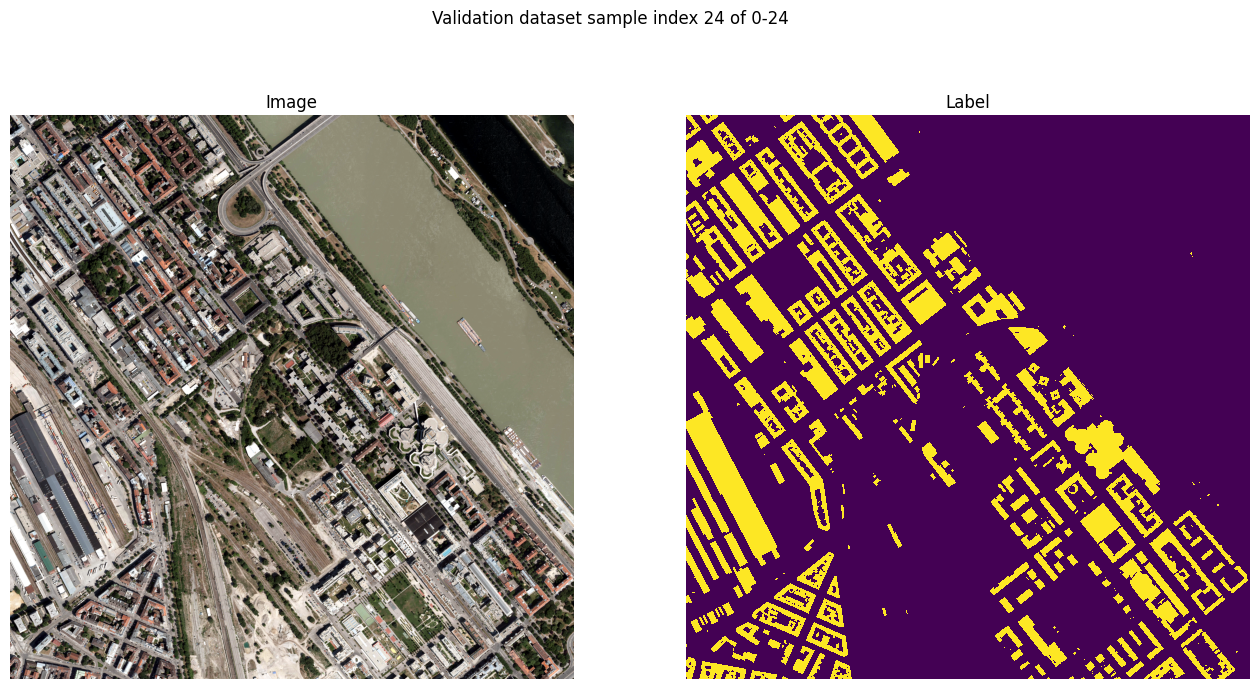

In [129]:
sample = datamodule.val_dataset[idx_val]
datamodule.plot(sample, suptitle=f"Validation dataset sample index {idx_val} of 0-24")

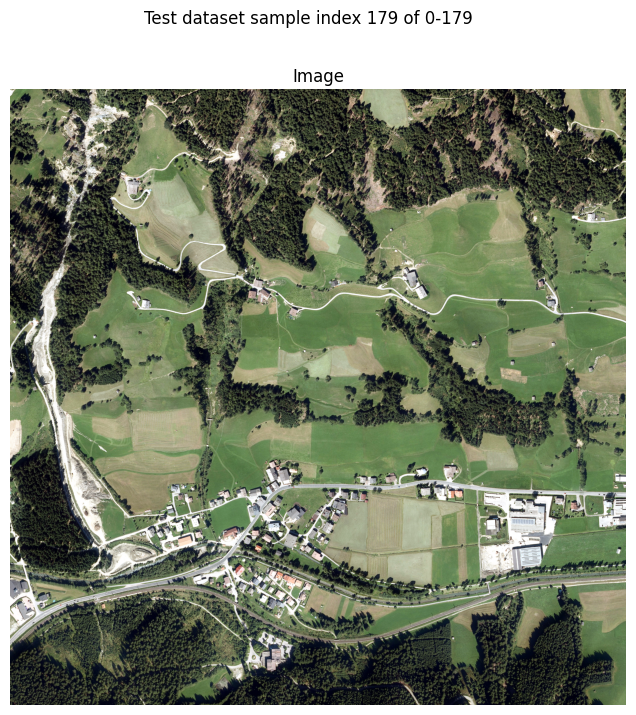

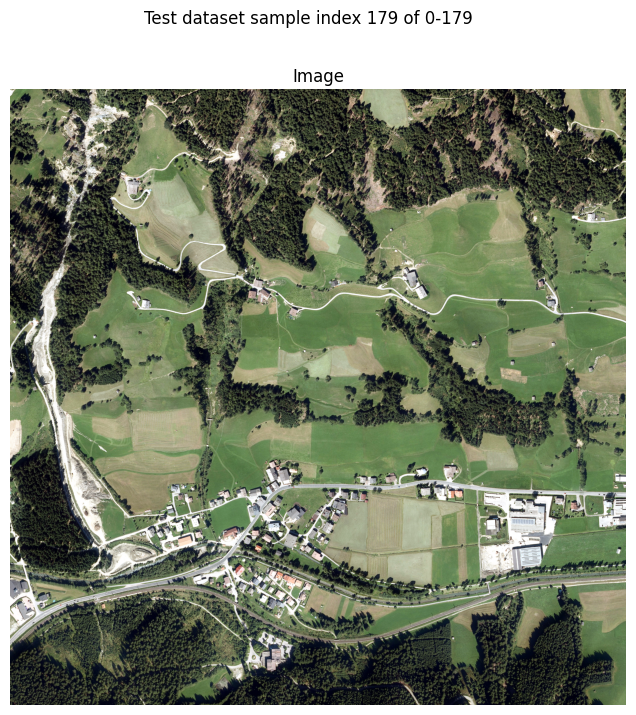

In [130]:
sample = datamodule.predict_dataset[idx_pr]
datamodule.plot(sample, suptitle=f"Test dataset sample index {idx_pr} of 0-179")